In [ ]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=077979a438703c932a3fea7daa014aebecead2b4831bc1108a98a92b55c26874
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


(a) mpg 中位數 = 22.75；mpg01=1 代表高於中位數
    mpg  mpg01
0  18.0      0
1  15.0      0
2  18.0      0
3  16.0      0
4  17.0      0

(b) 數值相關係數（與 mpg 的關聯作參考）：
mpg             1.000000
year            0.580541
origin          0.565209
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


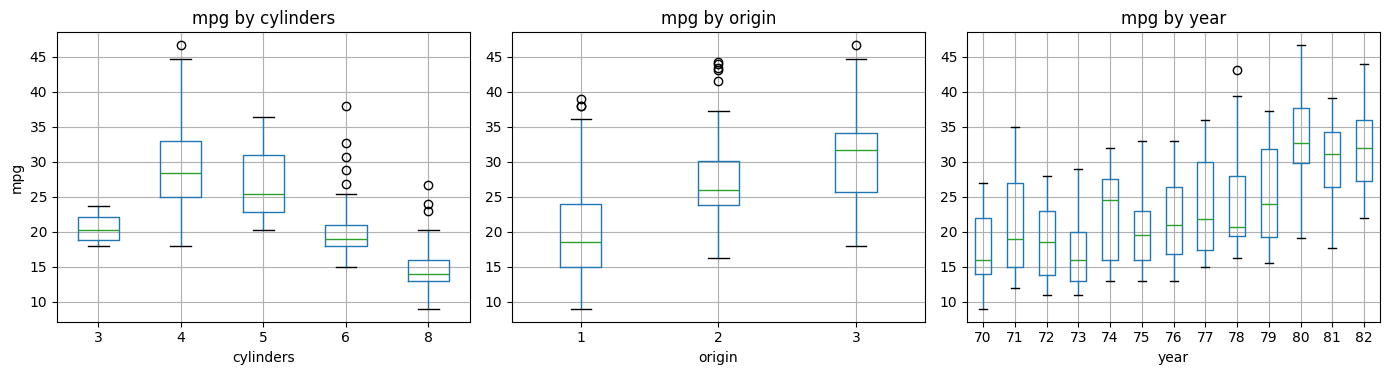

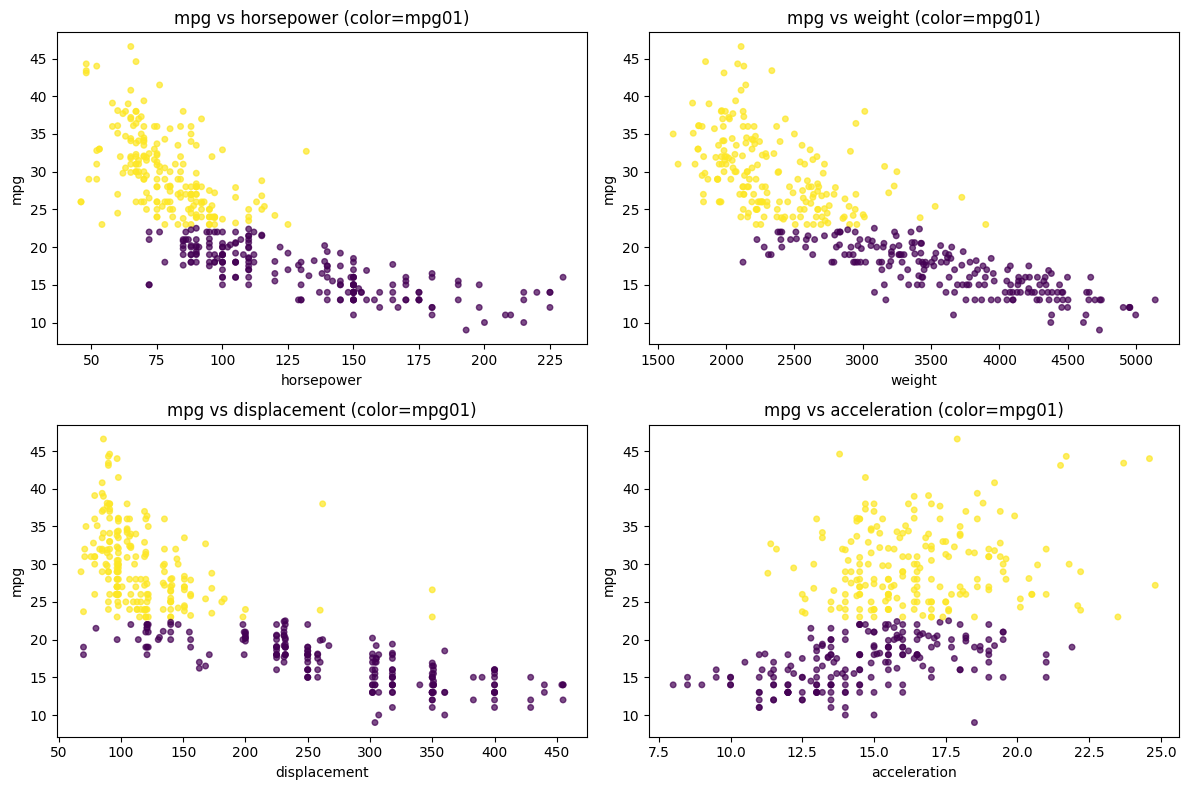


(b) 後續模型將優先使用特徵： ['cylinders', 'displacement', 'horsepower', 'weight', 'year']

(c) 訓練集大小: 274，測試集大小: 118

(d) LDA
Accuracy: 0.9152542372881356
Confusion matrix:
 [[49 10]
 [ 0 59]]

(e) QDA
Accuracy: 0.8898305084745762
Confusion matrix:
 [[49 10]
 [ 3 56]]

(f) Logistic Regression
Accuracy: 0.923728813559322
Confusion matrix:
 [[52  7]
 [ 2 57]]

(g) Naive Bayes (Gaussian)
Accuracy: 0.8983050847457628
Confusion matrix:
 [[51  8]
 [ 4 55]]

(h) KNN 測試錯誤率（= 1 - Accuracy）：
K= 1: error=0.0932 (acc=0.9068)
K= 3: error=0.0763 (acc=0.9237)
K= 5: error=0.0763 (acc=0.9237)
K= 7: error=0.0678 (acc=0.9322)
K= 9: error=0.0932 (acc=0.9068)
K=11: error=0.1017 (acc=0.8983)
K=13: error=0.1017 (acc=0.8983)
K=15: error=0.1017 (acc=0.8983)
K=17: error=0.1017 (acc=0.8983)
K=21: error=0.1017 (acc=0.8983)
K=25: error=0.1017 (acc=0.8983)
K=31: error=0.0932 (acc=0.9068)

最佳 K = 7，測試 Accuracy=0.9322；Confusion matrix:
[[53  6]
 [ 2 57]]

=== 總結：各模型測試表現（依 Accuracy 排序） ===
     Model  Accuracy  TestError
  KNN(

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# (a) 載入資料並建立二元變數 mpg01
Auto = load_data('Auto')  # 欄位常見: mpg, cylinders, displacement, horsepower, weight, acceleration, year, origin, name
# 若 horsepower 為字串，轉成數值（ISLP 通常已清理好）
if Auto['horsepower'].dtype == 'O':
    Auto['horsepower'] = pd.to_numeric(Auto['horsepower'], errors='coerce')
Auto = Auto.dropna().reset_index(drop=True)

mpg_median = Auto['mpg'].median()
Auto['mpg01'] = (Auto['mpg'] > mpg_median).astype(int)

print(f"(a) mpg 中位數 = {mpg_median:.2f}；mpg01=1 代表高於中位數")
print(Auto[['mpg','mpg01']].head())

# (b) 圖形探索：mpg01 與其他特徵的關聯
num_cols = ['cylinders','displacement','horsepower','weight','acceleration','year','origin']
print("\n(b) 數值相關係數（與 mpg 的關聯作參考）：")
print(Auto[['mpg']+num_cols].corr()['mpg'].sort_values(ascending=False))

# 箱型圖：離散/等級變數 vs mpg 或 vs mpg01
fig, axes = plt.subplots(1, 3, figsize=(14,4))
Auto.boxplot(column='mpg', by='cylinders', ax=axes[0])
axes[0].set_title('mpg by cylinders'); axes[0].set_xlabel('cylinders'); axes[0].set_ylabel('mpg')
Auto.boxplot(column='mpg', by='origin', ax=axes[1])
axes[1].set_title('mpg by origin'); axes[1].set_xlabel('origin')
Auto.boxplot(column='mpg', by='year', ax=axes[2])
axes[2].set_title('mpg by year'); axes[2].set_xlabel('year')
plt.suptitle(''); plt.tight_layout(); plt.show()

# 散佈圖：連續變數 vs mpg，並以 mpg01 著色（用 marker 還是顏色區分）
fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.ravel()
pairs = [('horsepower','mpg'), ('weight','mpg'), ('displacement','mpg'), ('acceleration','mpg')]
for ax, (x,y) in zip(axes, pairs):
    ax.scatter(Auto[x], Auto[y], c=Auto['mpg01'], s=16, alpha=0.7)
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(f'{y} vs {x} (color=mpg01)')
plt.tight_layout(); plt.show()

# 依經典 ISL 結果，通常與 mpg01 關聯度高的包含：
# cylinders, displacement, horsepower, weight（負相關），year（正相關）。
selected_features = ['cylinders','displacement','horsepower','weight','year']
print("\n(b) 後續模型將優先使用特徵：", selected_features)

# (c) 訓練/測試切分（固定隨機種子，並做 stratify 以平衡類別）
X = Auto[selected_features].values
y = Auto['mpg01'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\n(c) 訓練集大小: {X_train.shape[0]}，測試集大小: {X_test.shape[0]}")

def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred)
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Confusion matrix:\n", cm)
    return acc, cm

# (d) LDA（使用 (b) 選出的特徵）
lda = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
lda.fit(X_train, y_train)
acc_lda, cm_lda = report("(d) LDA", y_test, lda.predict(X_test))

# (e) QDA
# 註：QDA 對尺度也敏感，雖然協方差內部會反映尺度，實務上常仍先標準化
qda = make_pipeline(StandardScaler(), QuadraticDiscriminantAnalysis())
qda.fit(X_train, y_train)
acc_qda, cm_qda = report("(e) QDA", y_test, qda.predict(X_test))

# (f) Logistic Regression
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logit.fit(X_train, y_train)
acc_logit, cm_logit = report("(f) Logistic Regression", y_test, logit.predict(X_test))

# (g) Naive Bayes（GaussianNB）
# NB 對尺度不嚴格，但為與其他法一致亦可標準化（兩種都行）
nb = make_pipeline(StandardScaler(), GaussianNB())
nb.fit(X_train, y_train)
acc_nb, cm_nb = report("(g) Naive Bayes (Gaussian)", y_test, nb.predict(X_test))

# (h) KNN 多個 K（只用 (b) 的特徵）
knn_results = {}
for k in [1,3,5,7,9,11,13,15,17,21,25,31]:
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_results[k] = (acc, confusion_matrix(y_test, y_pred))

print("\n(h) KNN 測試錯誤率（= 1 - Accuracy）：")
for k, (acc, cm) in knn_results.items():
    print(f"K={k:>2d}: error={1-acc:.4f} (acc={acc:.4f})")

# 挑最佳 K
best_k = max(knn_results, key=lambda k: knn_results[k][0])
best_acc, best_cm = knn_results[best_k]
print(f"\n最佳 K = {best_k}，測試 Accuracy={best_acc:.4f}；Confusion matrix:\n{best_cm}")

# 彙整比較
summary = [
    ("LDA", acc_lda, cm_lda),
    ("QDA", acc_qda, cm_qda),
    ("Logistic", acc_logit, cm_logit),
    ("NaiveBayes", acc_nb, cm_nb),
    (f"KNN(k={best_k})", best_acc, best_cm),
]
summary_df = pd.DataFrame(
    [(m, acc, 1-acc) for (m, acc, cm) in summary],
    columns=["Model","Accuracy","TestError"]
).sort_values(by="Accuracy", ascending=False)
print("\n=== 總結：各模型測試表現（依 Accuracy 排序） ===")
print(summary_df.to_string(index=False))
